In [ ]:
import pandas as pd
import numpy as np

# About the Dataset
https://www.kaggle.com/datasets/sahilislam007/college-student-placement-factors-dataset

College Student Placement Dataset
A realistic, large-scale synthetic dataset of 10,000 students designed to analyze factors affecting college placements.

Dataset Description
This dataset simulates the academic and professional profiles of 10,000 college students, focusing on factors that influence placement outcomes. It includes features like IQ, academic performance, CGPA, internships, communication skills, and more.

The dataset is ideal for:

Predictive modeling of placement outcomes
Educational exercises in classification
Feature importance analysis
End-to-end machine learning projects


In [3]:
df = pd.read_csv("college_student_placement_syn.csv")
df

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0049,74.541318,NaN,NaN,4.065632,Yes,7.962026,2.984785,0.037274,No
1,CLG0072,102.979046,7.747007,7.582950,NaN,No,8.049046,3.026682,2.014086,No
2,CLG0093,89.461004,7.082186,NaN,0.974574,Yes,9.985005,1.060344,4.997038,No
3,CLG0056,99.364693,7.723489,7.348178,9.008038,No,7.018519,10.028812,-0.037550,No
4,CLG0037,90.811987,9.933312,9.702759,6.012124,No,7.980459,7.972480,0.982337,No
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0027,115.400272,8.285923,8.501344,6.026629,No,NaN,1.012514,4.024810,Yes
9996,CLG0084,130.660778,7.201784,6.895113,2.080016,Yes,0.920835,8.007006,4.994075,Yes
9997,CLG0052,88.174905,9.089913,8.646627,4.020334,Yes,5.966982,9.956674,4.052551,Yes
9998,CLG0047,91.074942,5.929101,5.645560,4.007506,No,NaN,8.027624,4.019559,No


In [4]:
print(df.shape)
print(df.info())

(10000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              9513 non-null   object 
 1   IQ                      9482 non-null   float64
 2   Prev_Sem_Result         9462 non-null   float64
 3   CGPA                    9487 non-null   float64
 4   Academic_Performance    9525 non-null   float64
 5   Internship_Experience   9494 non-null   object 
 6   Extra_Curricular_Score  9527 non-null   float64
 7   Communication_Skills    9487 non-null   float64
 8   Projects_Completed      9535 non-null   float64
 9   Placement               9449 non-null   object 
dtypes: float64(7), object(3)
memory usage: 781.4+ KB
None


In [5]:
print(df.describe())

                IQ  Prev_Sem_Result         CGPA  Academic_Performance  \
count  9482.000000      9462.000000  9487.000000           9525.000000   
mean     99.534077         7.534913     7.533118              5.537468   
std      15.020969         1.447898     1.475839              2.884854   
min      43.922110         4.921910     4.484996              0.817254   
25%      89.636598         6.297948     6.277548              2.998786   
50%      99.461932         7.542532     7.541053              5.919687   
75%     109.790857         8.785071     8.786179              8.005146   
max     157.832451        10.060510    10.469513             10.176889   

       Extra_Curricular_Score  Communication_Skills  Projects_Completed  
count             9527.000000           9487.000000         9535.000000  
mean                 4.947669              5.547235            2.540978  
std                  3.189583              2.928345            1.723479  
min                 -0.216030        

Finding Missing Values

In [6]:
df.isnull()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,False,False,True,True,False,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,True,False,False,False
9996,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,True,False,False,False


In [7]:
#drop unnessassary columns
df = df.drop(columns=['College_ID'], axis=1)

# Finding Numeric and categorical columns

In [8]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

print('Numberic:', len(num_cols))
print('Categorical:', len(cat_cols))



Numberic: 7
Categorical: 2


### Encoding

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [10]:
#print(df.isnull())
null_rows = df[df.isnull().any(axis=1)]
print(null_rows)

              IQ  Prev_Sem_Result      CGPA  Academic_Performance  \
0      74.541318              NaN       NaN              4.065632   
1     102.979046         7.747007  7.582950                   NaN   
2      89.461004         7.082186       NaN              0.974574   
12    109.627432         6.474131       NaN              1.032785   
14           NaN         9.004123  9.464065              5.935169   
...          ...              ...       ...                   ...   
9992   83.866119         7.696218  7.556275              5.982103   
9994   95.116017              NaN  8.952560              8.068052   
9995  115.400272         8.285923  8.501344              6.026629   
9998   91.074942         5.929101  5.645560              4.007506   
9999   76.200282         8.691516  8.742073             10.015642   

     Internship_Experience  Extra_Curricular_Score  Communication_Skills  \
0                      Yes                7.962026              2.984785   
1                  

## Data Imputation
Handling missing values

In [11]:
# Fill numeric columns with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical columns with mode
df['Internship_Experience'] = df['Internship_Experience'].fillna(df['Internship_Experience'].mode()[0])
df['Placement'] = df['Placement'].fillna(df['Placement'].mode()[0])

In [12]:
# Convert 'Yes'/'No' into 1/0
yes_no_cols = ['Internship_Experience', 'Placement']
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print(df[yes_no_cols].head())

   Internship_Experience  Placement
0                      1          0
1                      0          0
2                      1          0
3                      0          0
4                      0          0


In [13]:
df

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,74.541318,7.542532,7.541053,4.065632,1,7.962026,2.984785,0.037274,0
1,102.979046,7.747007,7.582950,5.919687,0,8.049046,3.026682,2.014086,0
2,89.461004,7.082186,7.541053,0.974574,1,9.985005,1.060344,4.997038,0
3,99.364693,7.723489,7.348178,9.008038,0,7.018519,10.028812,-0.037550,0
4,90.811987,9.933312,9.702759,6.012124,0,7.980459,7.972480,0.982337,0
...,...,...,...,...,...,...,...,...,...
9995,115.400272,8.285923,8.501344,6.026629,0,4.980147,1.012514,4.024810,1
9996,130.660778,7.201784,6.895113,2.080016,1,0.920835,8.007006,4.994075,1
9997,88.174905,9.089913,8.646627,4.020334,1,5.966982,9.956674,4.052551,1
9998,91.074942,5.929101,5.645560,4.007506,0,4.980147,8.027624,4.019559,0


## Train_Test_Split

In [14]:
# define the target variable or output class
target = "Placement"

In [15]:
#seperate X and Y
X = df.drop(target, axis=1)
y = df[target]

In [16]:
#Training and Testing Data (divide the data into two part)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=.3, random_state=42)

## Normalize / Standardize
I choose to standardize as in some columns we have some outliers

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Cross Validation
We must do cross-validation as we want to avoid overfitting
Instead of one tran/test split we will use K-fold CV as it will help us to iterate through all the datapoints in the dataset

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# # Create models dictionary
# models = {
#     "LinearRegression": LinearRegression(),
#     "KNN": KNeighborsRegressor(n_neighbors=5),
#     "Decision Tree": DecisionTreeClassifier(random_state=42),
#     "Random Forest": RandomForestClassifier(random_state=42),
#     "AdaBoost": AdaBoostClassifier(random_state=42)
# }

# Train models and evalaute all models one-by-one

Also finding Accuracy, Precision, Recall, F1-Score, Specificity, ROC-AUC, and Confusion Matrix.

In [ ]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
mae_lr = mean_absolute_error(y_test, pred_lr)
r2_lr = r2_score(y_test, pred_lr)

print("LinearRegression")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)


LinearRegression
RMSE: 0.30513397254859814
MAE: 0.23481408780914437
R2: 0.3186757697133119



=== KNN Classifier ===
Accuracy: 0.9166666666666666
Precision: 0.7620087336244541
Recall: 0.7122448979591837
F1-Score: 0.7362869198312236
Specificity: 0.9565737051792829
ROC-AUC: 0.9459374745914302

Confusion Matrix:
[[2401  109]
 [ 141  349]]


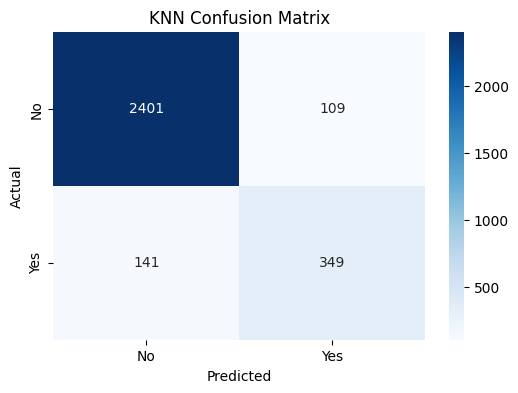

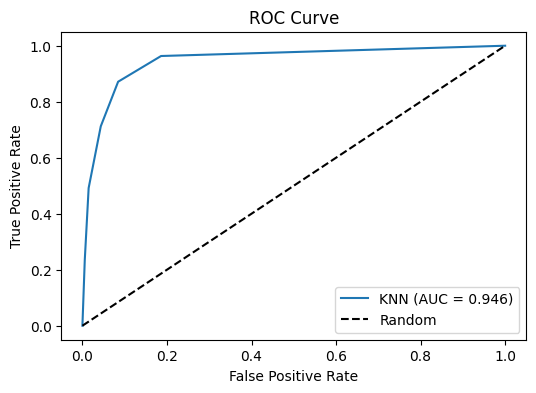

In [21]:
# KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)
pred_knn_proba = knn.predict_proba(X_test)[:, 1]  # Probability for class 1

print("\n=== KNN Classifier ===")
print("Accuracy:", accuracy_score(y_test, pred_knn))
print("Precision:", precision_score(y_test, pred_knn))
print("Recall:", recall_score(y_test, pred_knn))
print("F1-Score:", f1_score(y_test, pred_knn))

# Specificity = TN / (TN + FP)
cm = confusion_matrix(y_test, pred_knn)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print("Specificity:", specificity)

print("ROC-AUC:", roc_auc_score(y_test, pred_knn_proba))

# Confusion Matrix
print("\nConfusion Matrix:")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('KNN Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, pred_knn_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='KNN (AUC = {:.3f})'.format(roc_auc_score(y_test, pred_knn_proba)))
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


=== Decision Tree Classifier ===
Accuracy: 0.974
Precision: 0.917004048582996
Recall: 0.9244897959183673
F1-Score: 0.9207317073170732
Specificity: 0.9836653386454183
ROC-AUC: 0.9668147816895682

Confusion Matrix:
[[2469   41]
 [  37  453]]


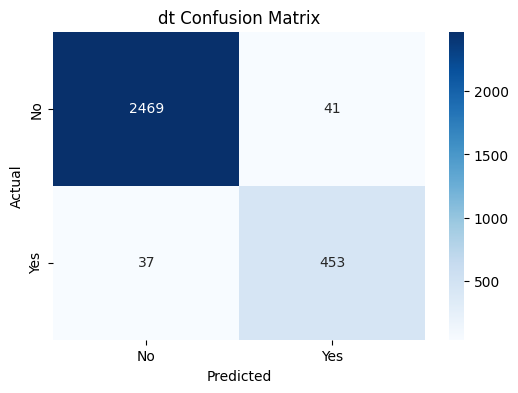

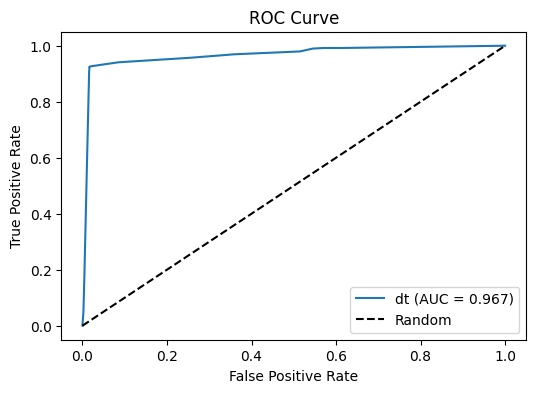

In [22]:
#DECISION Tree
dt = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)
pred_dt_proba = dt.predict_proba(X_test)[:, 1]  # Probability for class 1


print("\n=== Decision Tree Classifier ===")
print("Accuracy:", accuracy_score(y_test, pred_dt))
print("Precision:", precision_score(y_test, pred_dt))
print("Recall:", recall_score(y_test, pred_dt))
print("F1-Score:", f1_score(y_test, pred_dt))

# Specificity = TN / (TN + FP)
cm = confusion_matrix(y_test, pred_dt)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print("Specificity:", specificity)

print("ROC-AUC:", roc_auc_score(y_test, pred_dt_proba))

# Confusion Matrix
print("\nConfusion Matrix:")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('dt Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, pred_dt_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='dt (AUC = {:.3f})'.format(roc_auc_score(y_test, pred_dt_proba)))
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()



=== Random Forest Classifier ===
Accuracy: 0.9166666666666666
Precision: 0.7620087336244541
Recall: 0.7122448979591837
F1-Score: 0.7362869198312236
Specificity: 0.9565737051792829
ROC-AUC: 0.9459374745914302

Confusion Matrix:
[[2401  109]
 [ 141  349]]


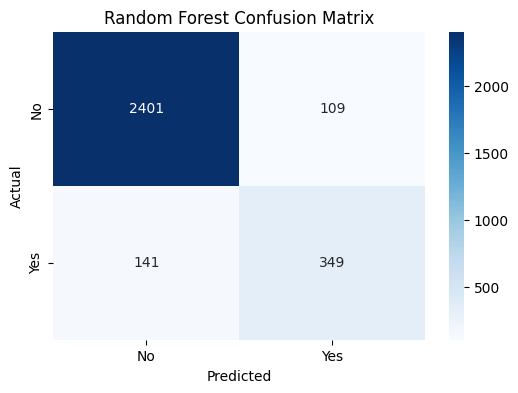

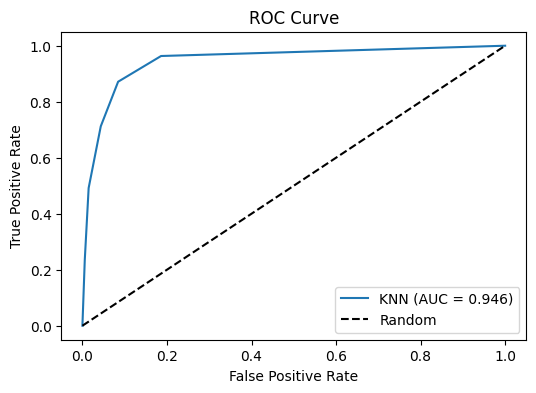

In [23]:
#Random Forest
rf = RandomForestClassifier(n_estimators=40, criterion='gini', max_depth=20,  random_state=5)
rf.fit(X_train, y_train)

pred_rf = knn.predict(X_test)
pred_rf_proba = knn.predict_proba(X_test)[:, 1]  # Probability for class 1

print("\n=== Random Forest Classifier ===")
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1-Score:", f1_score(y_test, pred_rf))

# Specificity = TN / (TN + FP)
cm = confusion_matrix(y_test, pred_rf)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print("Specificity:", specificity)

print("ROC-AUC:", roc_auc_score(y_test, pred_rf_proba))

# Confusion Matrix
print("\nConfusion Matrix:")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, pred_rf_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='KNN (AUC = {:.3f})'.format(roc_auc_score(y_test, pred_rf_proba)))
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()



=== AdaBoost Classifier ===
Accuracy: 0.8366666666666667
Precision: 0.0
Recall: 0.0
F1-Score: 0.0
Specificity: 1.0
ROC-AUC: 0.9422741686315961

Confusion Matrix:
[[2510    0]
 [ 490    0]]


c:\ML\ml_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


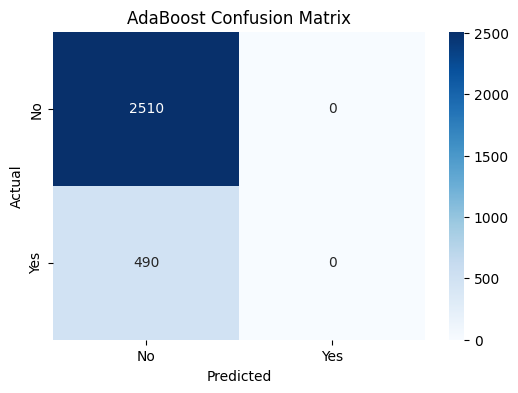

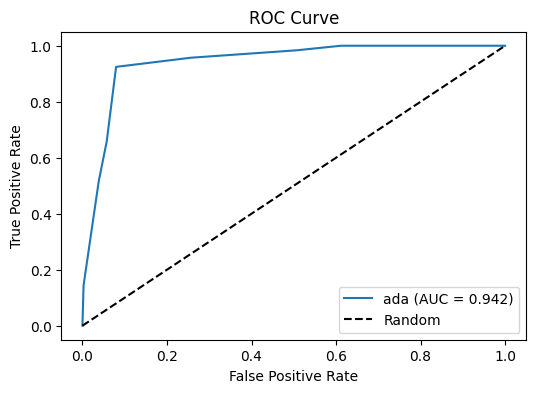

In [27]:
# AdaBoost
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.01, random_state=42)
ada.fit(X_train, y_train)

pred_ada = ada.predict(X_test)
pred_ada_proba = ada.predict_proba(X_test)[:, 1]  # Probability for class 1

print("\n=== AdaBoost Classifier ===")
print("Accuracy:", accuracy_score(y_test, pred_ada))
print("Precision:", precision_score(y_test, pred_ada))
print("Recall:", recall_score(y_test, pred_ada))
print("F1-Score:", f1_score(y_test, pred_ada))

# Specificity = TN / (TN + FP)
cm = confusion_matrix(y_test, pred_ada)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print("Specificity:", specificity)

print("ROC-AUC:", roc_auc_score(y_test, pred_ada_proba))

# Confusion Matrix
print("\nConfusion Matrix:")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('AdaBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, pred_ada_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='ada (AUC = {:.3f})'.format(roc_auc_score(y_test, pred_ada_proba)))
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()



=== AdaBoost Classifier ===
Accuracy: 0.8906666666666667
Precision: 0.6919431279620853
Recall: 0.5959183673469388
F1-Score: 0.6403508771929824
Specificity: 1.0
ROC-AUC: 0.9074680868363282

Confusion Matrix:
[[2510    0]
 [ 490    0]]


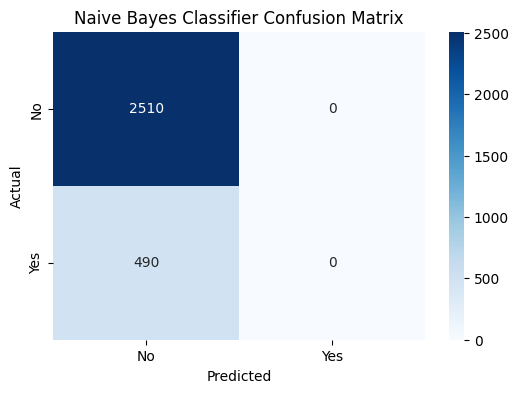

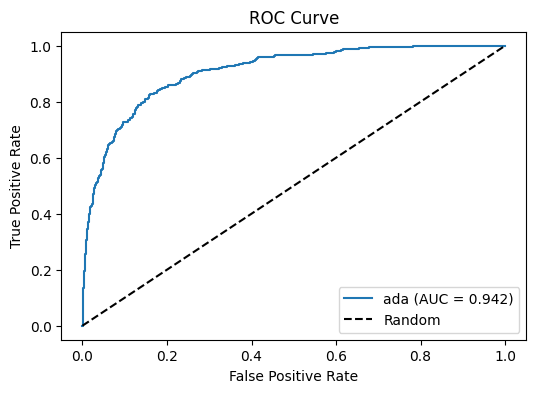

In [29]:
# Naive Bayes Classifier
nb = GaussianNB()
nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)
pred_nb_proba = nb.predict_proba(X_test)[:, 1]  # Probability for class 1

print("\n=== AdaBoost Classifier ===")
print("Accuracy:", accuracy_score(y_test, pred_nb))
print("Precision:", precision_score(y_test, pred_nb))
print("Recall:", recall_score(y_test, pred_nb))
print("F1-Score:", f1_score(y_test, pred_nb))

# Specificity = TN / (TN + FP)
cm = confusion_matrix(y_test, pred_ada)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print("Specificity:", specificity)

print("ROC-AUC:", roc_auc_score(y_test, pred_nb_proba))

# Confusion Matrix
print("\nConfusion Matrix:")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Naive Bayes Classifier Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, pred_nb_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='ada (AUC = {:.3f})'.format(roc_auc_score(y_test, pred_ada_proba)))
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
